In [2]:
# Importa bibliotecas essenciais para álgebra vetorial e gráficos.
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Configuração de estilo do gráfico e tamanho da figura.
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (10, 8)

# Criar o Dataset

In [4]:
def get_line_curve(x, w, b=0, noise_scale=0):
    """Gera uma linha y = w * x + b com ruído gaussiano."""
    # np.random.randn produz ruído normal padrão.
    return w * x + b + noise_scale * np.random.randn(x.shape[0])

In [5]:
# Cria as amostras de entrada x e os alvos Y com ruído.
x = np.arange(-10, 30.1, 0.5)
Y = get_line_curve(x, 1.8, 32, noise_scale=2.5)

# x é o conjunto de entradas e Y é o conjunto de alvos com ruído.

In [6]:
# Confirma a forma dos vetores de entrada e saída.
x.shape, Y.shape

((81,), (81,))

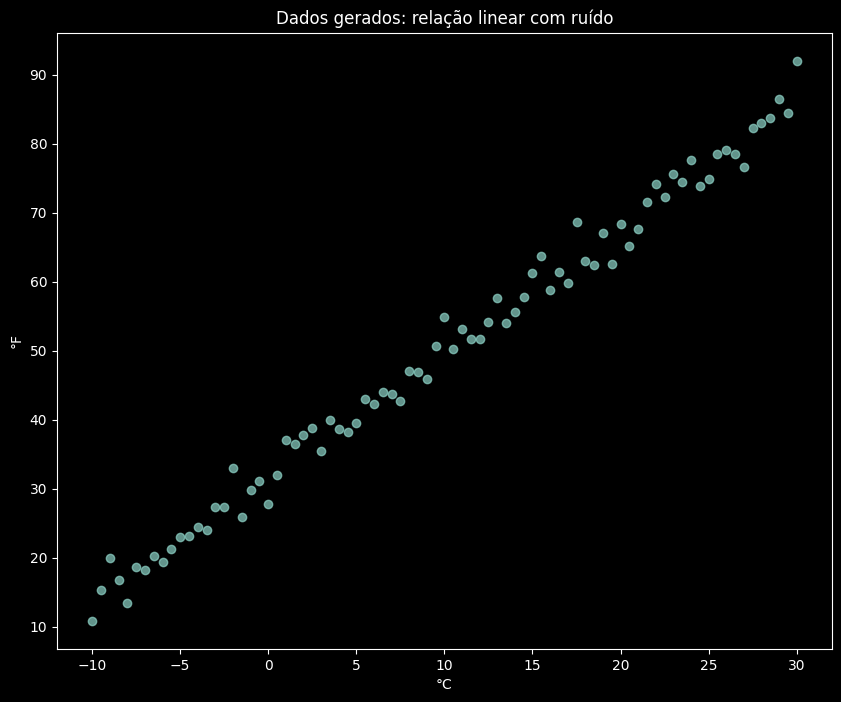

In [7]:
# Plota os dados gerados para verificar a relação linear com ruído.
plt.scatter(x, Y, alpha=0.7)
plt.xlabel('°C')
plt.ylabel('°F')
plt.title('Dados gerados: relação linear com ruído')
plt.show()

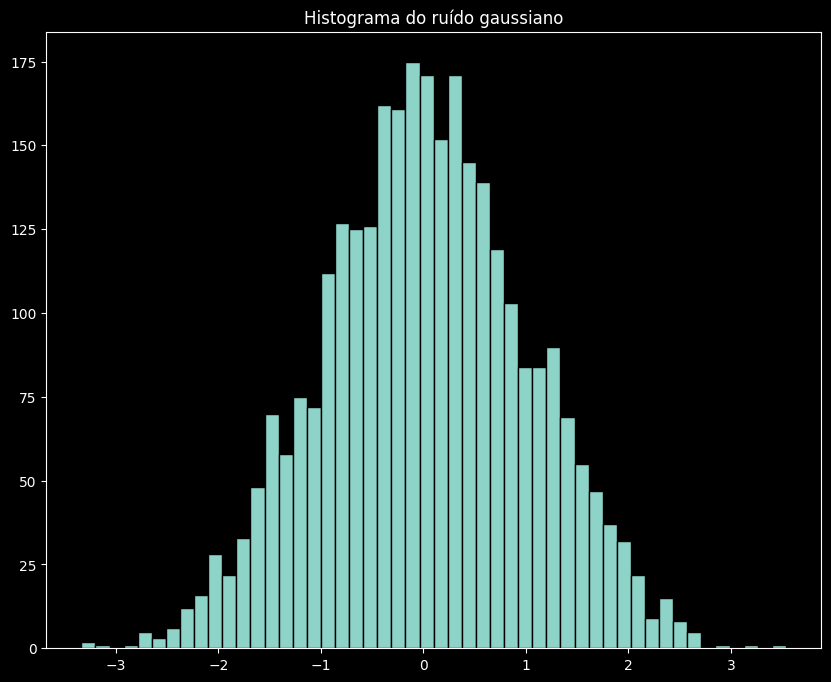

In [8]:
# Mostra um histograma da distribuição normal usada no ruído.
plt.hist(np.random.randn(3000), bins=50, edgecolor='black')
plt.title('Histograma do ruído gaussiano')
plt.show()

# Modelo

- Inicialização dos pesos e bias
- Feedforward
- Cálculo da perda
- Backpropagation
- Treinamento com descida de gradiente
- Avaliação do modelo

In [9]:
# Inicialização dos parâmetros do modelo linear.
# O treino vai ajustar w e b para aproximar a reta aos dados.
w = np.zeros(1)
b = np.zeros(1)

In [10]:
def forward(inputs, w, b):
    """Retorna as previsões do modelo linear para cada entrada."""
    return w * inputs + b

In [11]:
def mse(targets, outputs):
    """Calcula e retorna o erro quadrático médio."""
    return np.mean((targets - outputs) ** 2)

In [12]:
# Teste rápido da função de perda para garantir que funciona corretamente.
v = np.array([3, 4, 5])
u = np.array([3.2, 4.5, 4.8])
print('MSE exemplo:', mse(v, u))

MSE exemplo: 0.11000000000000006


In [13]:
def backpropagation(inputs, outputs, targets, w, b, lr):
    """Calcula os gradientes e atualiza os parâmetros usando descida de gradiente."""
    error = outputs - targets

    # dL/dw = 2/N * Σ(x * (y_pred - y_true))
    dw = 2 * np.mean(inputs * error)
    # dL/db = 2/N * Σ(y_pred - y_true)
    db = 2 * np.mean(error)

    w = w - lr * dw
    b = b - lr * db
    return w, b

In [14]:
def model_fit(inputs, targets, w, b, epochs=5000, lr=0.0001):
    """Treina o modelo usando descida de gradiente e salva a perda a cada época."""
    history = []

    for epoch in range(epochs):
        outputs = forward(inputs, w, b)
        loss = mse(targets, outputs)
        history.append(loss)

        # Atualiza os parâmetros com base nos gradientes calculados.
        w, b = backpropagation(inputs, outputs, targets, w, b, lr)

        if epoch == 0 or (epoch + 1) % 500 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}')

    return w, b, history

In [15]:
# Exibe a forma dos dados para confirmar que o dataset está correto.
print('Dataset criado: x shape =', x.shape, ', Y shape =', Y.shape)

Dataset criado: x shape = (81,) , Y shape = (81,)


In [16]:
# Inicialização do modelo antes do treinamento
# Usamos w = 0 e b = 0 para que o algoritmo aprenda desde o início.
w = np.zeros(1)
b = np.zeros(1)
print(f'Parâmetros iniciais: w = {w[0]:.4f}, b = {b[0]:.4f}')

Parâmetros iniciais: w = 0.0000, b = 0.0000


Epoch 1/5000, Loss: 2943.7985
Epoch 500/5000, Loss: 518.9842
Epoch 1000/5000, Loss: 463.0021
Epoch 1500/5000, Loss: 413.1162
Epoch 2000/5000, Loss: 368.6627
Epoch 2500/5000, Loss: 329.0499
Epoch 3000/5000, Loss: 293.7507
Epoch 3500/5000, Loss: 262.2955
Epoch 4000/5000, Loss: 234.2656
Epoch 4500/5000, Loss: 209.2880
Epoch 5000/5000, Loss: 187.0304
Parâmetros aprendidos: w = 2.5671, b = 13.9799
Loss final no treino: 186.9884


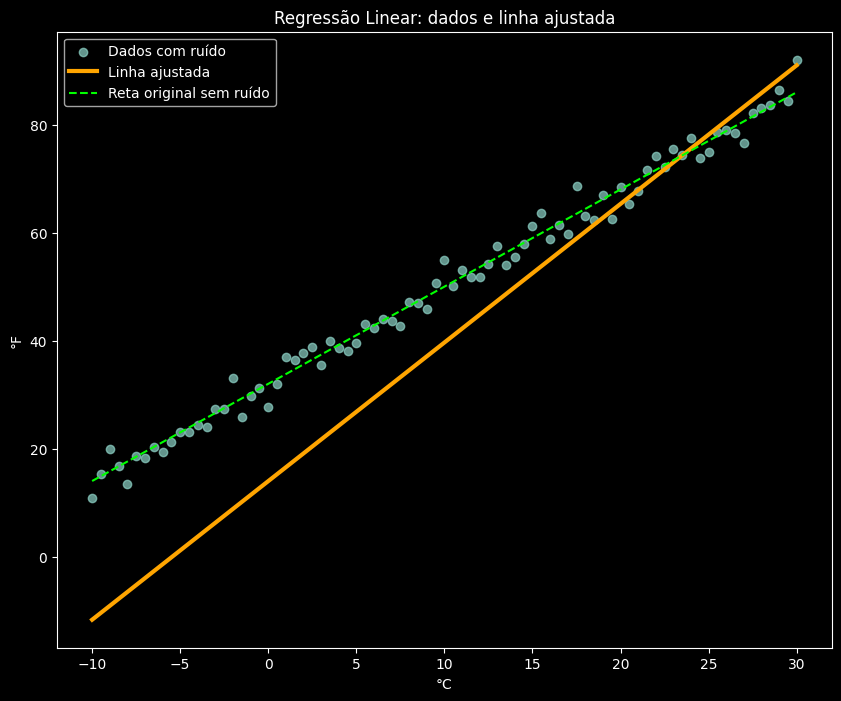

In [17]:
# Treinamento do modelo e avaliação dos resultados.
w, b, history = model_fit(x, Y, w, b, epochs=5000, lr=0.0001)
print(f'Parâmetros aprendidos: w = {w[0]:.4f}, b = {b[0]:.4f}')

# Fazemos as previsões com os parâmetros aprendidos.
predictions = forward(x, w, b)
final_loss = mse(Y, predictions)
print(f'Loss final no treino: {final_loss:.4f}')

# Visualiza os dados com ruído, a linha ajustada e a reta original.
plt.scatter(x, Y, label='Dados com ruído', alpha=0.7)
plt.plot(x, predictions, color='orange', linewidth=3, label='Linha ajustada')
plt.plot(x, 1.8 * x + 32, '--', color='lime', label='Reta original sem ruído')
plt.xlabel('°C')
plt.ylabel('°F')
plt.legend()
plt.title('Regressão Linear: dados e linha ajustada')
plt.show()